Reading input files...

DETECTED RECHARGE METHODS
1. Chapman
2. Eckhardt
3. LH
4. Recession Analysis

GROUNDWATER STATION RANKING
Station_ID GW_Station  Distance_km  GW_Rank
    501060   49484004     0.928296        1
    501261   44445035     2.717842        1
    530020   56393712    13.206669        1
    550110   50516004     8.201482        1
    550190   49510947     9.385732        1
    550390   49510947     2.336066        1
    550490   51481216    16.674815        1
    550560   50516004    13.388182        1
    550620   51481216    12.050441        1
    550710   51481216    13.655950        1
    550762   51481216     4.196708        1
    550800   48511110     2.347686        1
    550810   49490997     1.748204        1
    550940   49486001     7.090678        1
    550961   51481216    14.293794        1
    551000   51481216     6.397237        1
    551100   48481979     2.483949        1
    551302   51481216    19.874261        1
    551310   51481216    17.300162

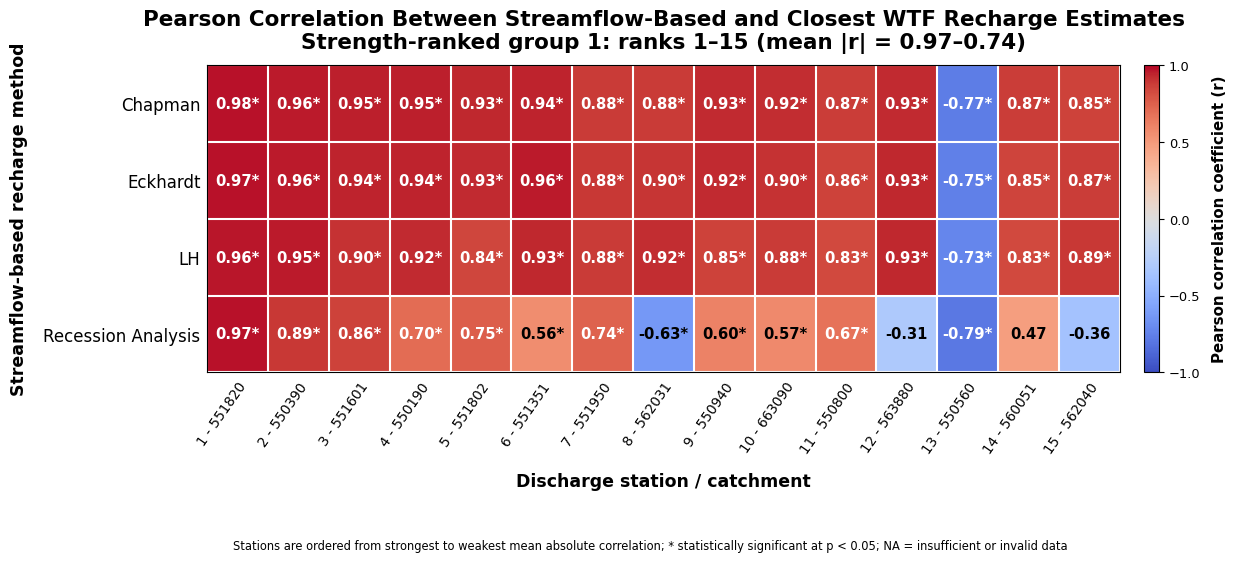


Created publication figure 2/7
  PNG: /kaggle/working/recharge_correlation_outputs/plots/Correlation_Heatmap_Group_2_600dpi.png
  SVG: /kaggle/working/recharge_correlation_outputs/plots/Correlation_Heatmap_Group_2_Vector.svg
  PDF: /kaggle/working/recharge_correlation_outputs/plots/Correlation_Heatmap_Group_2_Vector.pdf


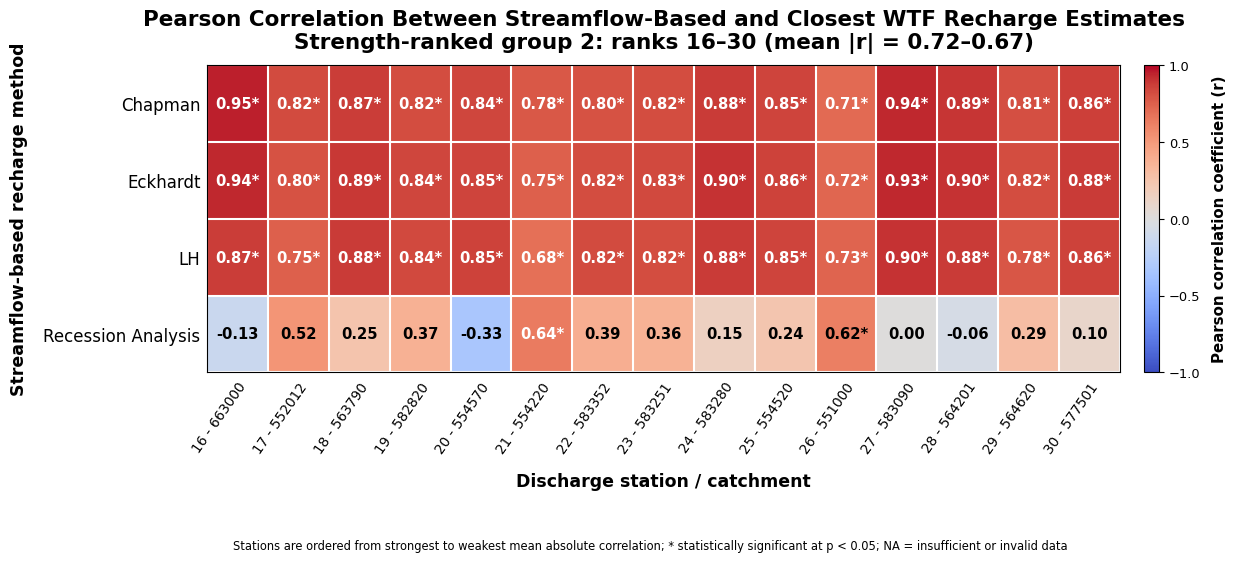


Created publication figure 3/7
  PNG: /kaggle/working/recharge_correlation_outputs/plots/Correlation_Heatmap_Group_3_600dpi.png
  SVG: /kaggle/working/recharge_correlation_outputs/plots/Correlation_Heatmap_Group_3_Vector.svg
  PDF: /kaggle/working/recharge_correlation_outputs/plots/Correlation_Heatmap_Group_3_Vector.pdf


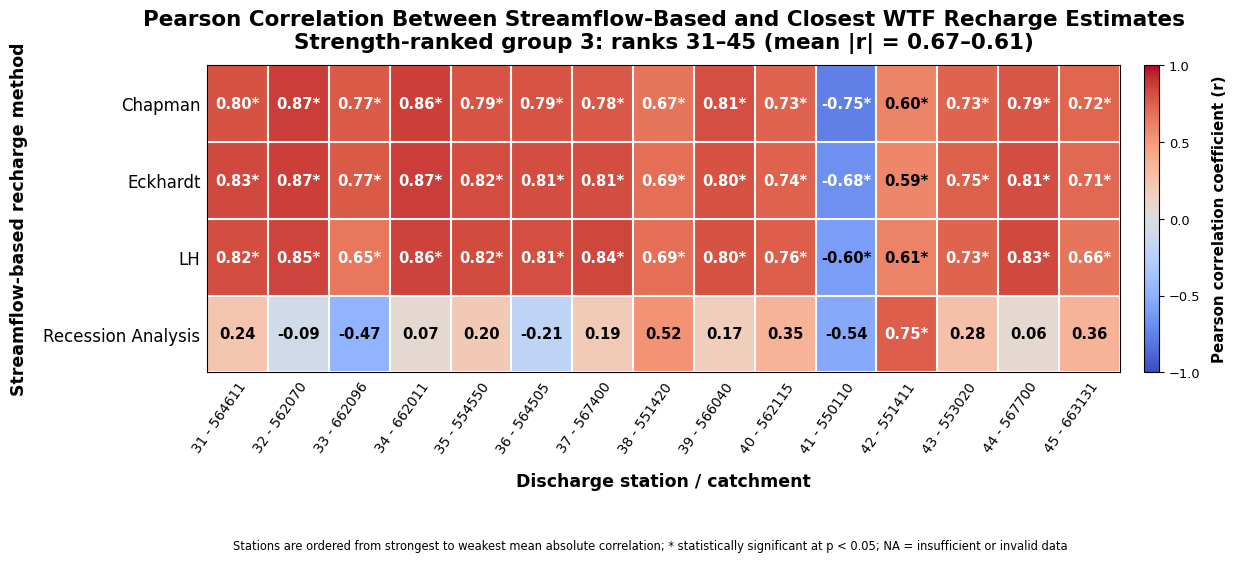


Created publication figure 4/7
  PNG: /kaggle/working/recharge_correlation_outputs/plots/Correlation_Heatmap_Group_4_600dpi.png
  SVG: /kaggle/working/recharge_correlation_outputs/plots/Correlation_Heatmap_Group_4_Vector.svg
  PDF: /kaggle/working/recharge_correlation_outputs/plots/Correlation_Heatmap_Group_4_Vector.pdf


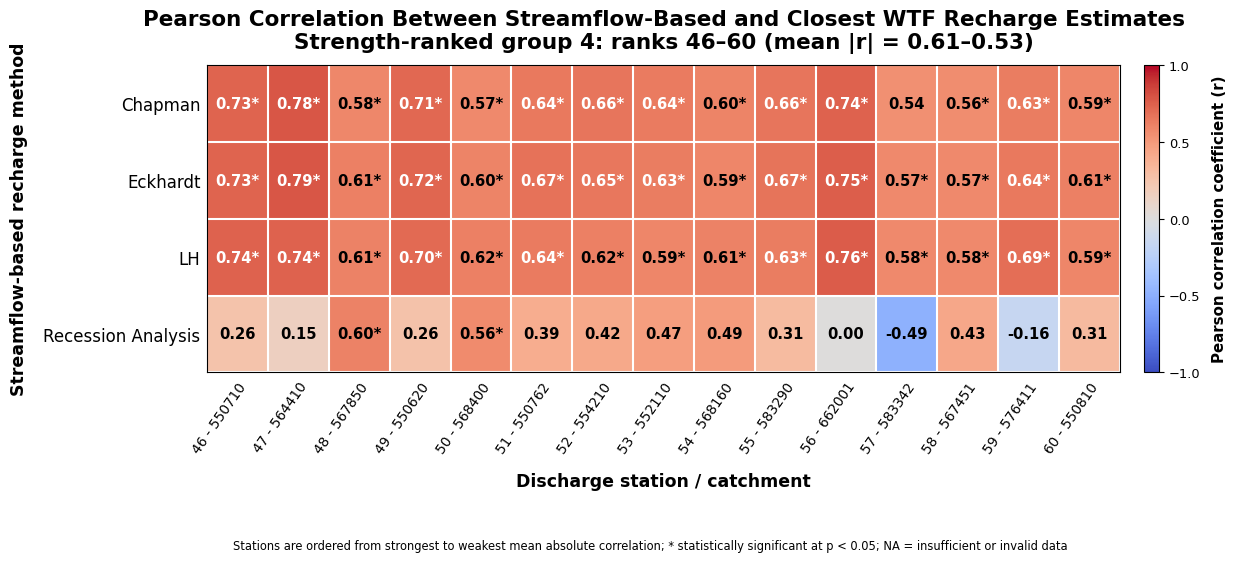


Created publication figure 5/7
  PNG: /kaggle/working/recharge_correlation_outputs/plots/Correlation_Heatmap_Group_5_600dpi.png
  SVG: /kaggle/working/recharge_correlation_outputs/plots/Correlation_Heatmap_Group_5_Vector.svg
  PDF: /kaggle/working/recharge_correlation_outputs/plots/Correlation_Heatmap_Group_5_Vector.pdf


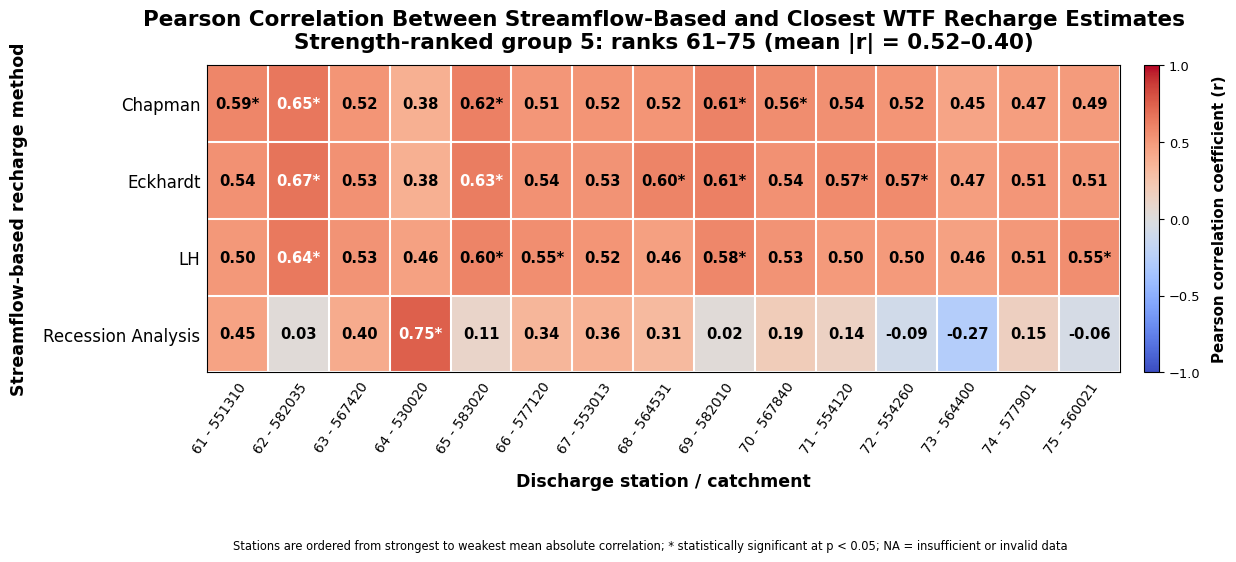


Created publication figure 6/7
  PNG: /kaggle/working/recharge_correlation_outputs/plots/Correlation_Heatmap_Group_6_600dpi.png
  SVG: /kaggle/working/recharge_correlation_outputs/plots/Correlation_Heatmap_Group_6_Vector.svg
  PDF: /kaggle/working/recharge_correlation_outputs/plots/Correlation_Heatmap_Group_6_Vector.pdf


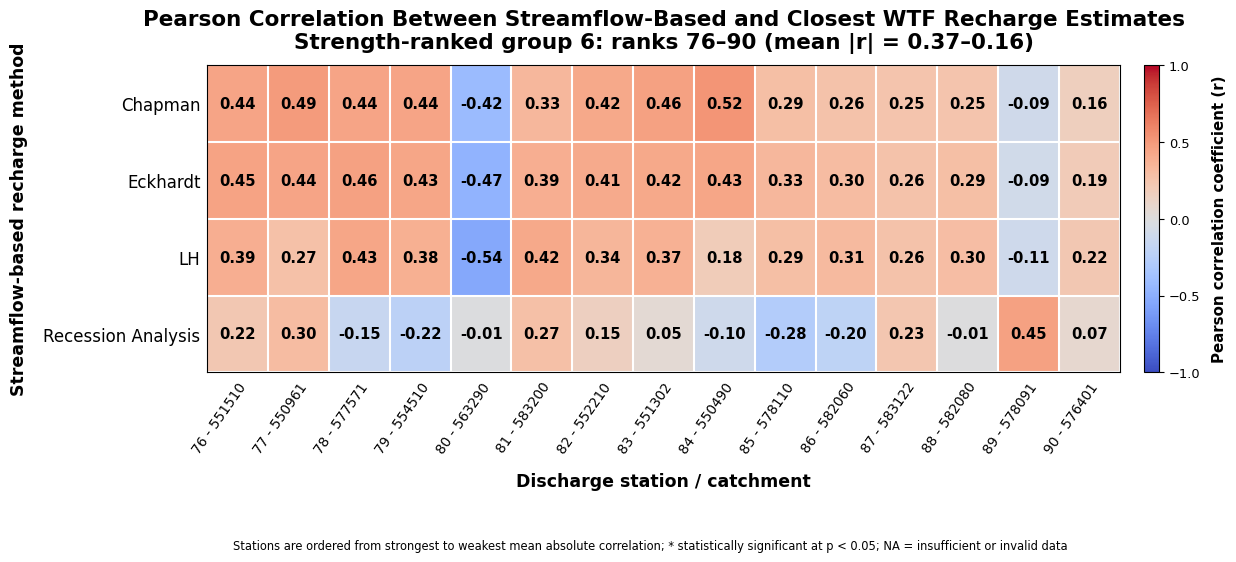


Created publication figure 7/7
  PNG: /kaggle/working/recharge_correlation_outputs/plots/Correlation_Heatmap_Group_7_600dpi.png
  SVG: /kaggle/working/recharge_correlation_outputs/plots/Correlation_Heatmap_Group_7_Vector.svg
  PDF: /kaggle/working/recharge_correlation_outputs/plots/Correlation_Heatmap_Group_7_Vector.pdf


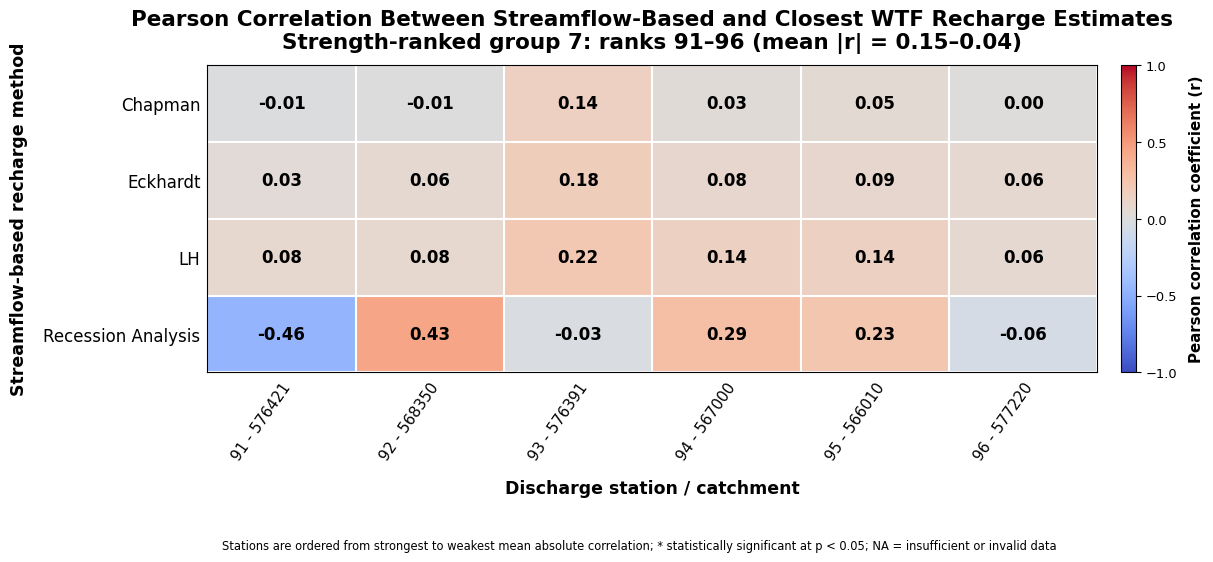


RECHARGE CORRELATION ANALYSIS COMPLETE

Number of streamflow recharge methods: 4
Number of discharge/catchment stations: 96
Publication figure groups created: 7
Stations per figure: 15
Groundwater rank used for publication plots: 1 (closest)

Publication PNG files:
  /kaggle/working/recharge_correlation_outputs/plots/Correlation_Heatmap_Group_1_600dpi.png
  /kaggle/working/recharge_correlation_outputs/plots/Correlation_Heatmap_Group_2_600dpi.png
  /kaggle/working/recharge_correlation_outputs/plots/Correlation_Heatmap_Group_3_600dpi.png
  /kaggle/working/recharge_correlation_outputs/plots/Correlation_Heatmap_Group_4_600dpi.png
  /kaggle/working/recharge_correlation_outputs/plots/Correlation_Heatmap_Group_5_600dpi.png
  /kaggle/working/recharge_correlation_outputs/plots/Correlation_Heatmap_Group_6_600dpi.png
  /kaggle/working/recharge_correlation_outputs/plots/Correlation_Heatmap_Group_7_600dpi.png

Excel workbook:
  /kaggle/working/recharge_correlation_outputs/tables/Recharge_Correlati

/kaggle/working/recharge_correlation_outputs.zip

In [6]:
# ============================================================
# RECHARGE CORRELATION ANALYSIS — PUBLICATION-QUALITY VERSION
# ============================================================
# Purpose
# -------
# 1. Compare streamflow-based recharge estimates with WTF recharge.
# 2. Use the nearest groundwater stations (up to four) for analysis.
# 3. Create publication-quality heatmaps using the CLOSEST GW station
#    (GW rank 1), matching the strength-ranked layout shown in the figure.
# 4. Rank discharge/catchment stations from strongest to weakest mean |r|.
# 5. Split stations into groups (default 24 per figure) so labels remain readable.
# 6. Save high-resolution PNG (600 dpi), SVG, PDF, CSV, Excel, and ZIP outputs.
# ============================================================

# ============================================================
# 1. INSTALL REQUIRED PACKAGES (KAGGLE / COLAB)
# ============================================================
# If scipy/openpyxl are already installed, this line is harmless.
!pip install scipy openpyxl -q

# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================
import os
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from IPython.display import FileLink, display

# ============================================================
# 3. FILE PATHS
# ============================================================
BASEFLOW_PATH = (
    "/kaggle/input/datasets/kausar15027/"
    "recharge-comparison-dataset/"
    "Baseflow_Time_Series_CSV.csv"
)

WTF_PATH = (
    "/kaggle/input/datasets/kausar15027/"
    "recharge-comparison-dataset/"
    "Recharge_WTF_Timeseries_CSV.csv"
)

CLOSE_PATH = (
    "/kaggle/input/datasets/kausar15027/"
    "recharge-comparison-dataset/"
    "Station_Closeness_CSV.csv"
)

# ============================================================
# 4. COLUMN SETTINGS
# ============================================================
STATION_COL = "Station_ID"
YEAR_COL = "Year"
GW_COL = "GW_Station"
RECHARGE_COL = "Recharge (mm)"
DIST_COL = "Distance_km"

# ============================================================
# 5. ANALYSIS SETTINGS
# ============================================================
ALPHA = 0.05
MIN_YEARS = 5
NUMBER_OF_GW_RANKS = 4

# Publication figure settings
PLOT_GW_RANK = 1           # 1 = closest WTF station
STATIONS_PER_FIGURE = 15   # 15 stations per figure for better readability
SAVE_DPI = 600

# Preferred method order for the heatmap.
# Any additional detected methods will be placed after these.
PREFERRED_METHOD_ORDER = [
    "Chapman",
    "Eckhardt",
    "LH",
    "Recession Analysis",
]

# ============================================================
# 6. OUTPUT DIRECTORIES
# ============================================================
OUT_DIR = "/kaggle/working/recharge_correlation_outputs"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
PLOT_DIR = os.path.join(OUT_DIR, "plots")

os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

# ============================================================
# 7. PLOT STYLE SETTINGS
# ============================================================
# Vector text remains editable/sharp in SVG and PDF.
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.family"] = "DejaVu Sans"

# ============================================================
# 8. HELPER FUNCTIONS
# ============================================================
def normalize_id(series):
    """Convert station IDs to clean strings so files match reliably."""
    s = series.astype(str).str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    return s


def numeric_sort_key(value):
    """Sort numeric-looking station IDs numerically, otherwise alphabetically."""
    try:
        return (0, float(value))
    except Exception:
        return (1, str(value))


def safe_mean_abs(series):
    """Mean absolute value while safely handling all-NaN groups."""
    values = pd.to_numeric(series, errors="coerce").to_numpy(dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan
    return float(np.mean(np.abs(values)))


def safe_median_abs(series):
    """Median absolute value while safely handling all-NaN groups."""
    values = pd.to_numeric(series, errors="coerce").to_numpy(dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan
    return float(np.median(np.abs(values)))


# ============================================================
# 9. READ INPUT DATA
# ============================================================
print("Reading input files...")

baseflow = pd.read_csv(BASEFLOW_PATH)
wtf = pd.read_csv(WTF_PATH)
close = pd.read_csv(CLOSE_PATH)

# Clean column names
baseflow.columns = baseflow.columns.astype(str).str.strip()
wtf.columns = wtf.columns.astype(str).str.strip()
close.columns = close.columns.astype(str).str.strip()

# ============================================================
# 10. CHECK REQUIRED COLUMNS
# ============================================================
required_baseflow = [STATION_COL, YEAR_COL]
required_wtf = [GW_COL, YEAR_COL, RECHARGE_COL]
required_close = [STATION_COL, GW_COL, DIST_COL]

missing_baseflow = [c for c in required_baseflow if c not in baseflow.columns]
missing_wtf = [c for c in required_wtf if c not in wtf.columns]
missing_close = [c for c in required_close if c not in close.columns]

if missing_baseflow:
    raise ValueError(f"Missing columns in Baseflow file: {missing_baseflow}")

if missing_wtf:
    raise ValueError(f"Missing columns in WTF file: {missing_wtf}")

if missing_close:
    raise ValueError(f"Missing columns in Station Closeness file: {missing_close}")

# ============================================================
# 11. CLEAN DATA TYPES
# ============================================================
# Normalize IDs so matching is not broken by int/string differences.
baseflow[STATION_COL] = normalize_id(baseflow[STATION_COL])
close[STATION_COL] = normalize_id(close[STATION_COL])
wtf[GW_COL] = normalize_id(wtf[GW_COL])
close[GW_COL] = normalize_id(close[GW_COL])

# Numeric fields
baseflow[YEAR_COL] = pd.to_numeric(baseflow[YEAR_COL], errors="coerce")
wtf[YEAR_COL] = pd.to_numeric(wtf[YEAR_COL], errors="coerce")
wtf[RECHARGE_COL] = pd.to_numeric(wtf[RECHARGE_COL], errors="coerce")
close[DIST_COL] = pd.to_numeric(close[DIST_COL], errors="coerce")

# Remove rows missing essential information
baseflow = baseflow.dropna(subset=[STATION_COL, YEAR_COL]).copy()
wtf = wtf.dropna(subset=[GW_COL, YEAR_COL, RECHARGE_COL]).copy()
close = close.dropna(subset=[STATION_COL, GW_COL, DIST_COL]).copy()

# Keep years as integers where possible
baseflow[YEAR_COL] = baseflow[YEAR_COL].astype(int)
wtf[YEAR_COL] = wtf[YEAR_COL].astype(int)

# ============================================================
# 12. AUTOMATICALLY DETECT RECHARGE METHODS
# ============================================================
# Every usable numeric column other than Station_ID and Year is treated
# as a streamflow-based recharge method, matching the logic of the
# original analysis.
candidate_methods = [
    c for c in baseflow.columns
    if c not in [STATION_COL, YEAR_COL]
]

METHODS_TO_PLOT = []

for col in candidate_methods:
    converted = pd.to_numeric(baseflow[col], errors="coerce")
    if converted.notna().any():
        baseflow[col] = converted
        METHODS_TO_PLOT.append(col)

if not METHODS_TO_PLOT:
    raise ValueError(
        "No numerical recharge-method columns were detected in the Baseflow CSV."
    )

# Reorder methods to match the desired figure when names are available.
preferred_present = [m for m in PREFERRED_METHOD_ORDER if m in METHODS_TO_PLOT]
remaining_methods = [m for m in METHODS_TO_PLOT if m not in preferred_present]
METHODS_TO_PLOT = preferred_present + remaining_methods

print("\n==============================================")
print("DETECTED RECHARGE METHODS")
print("==============================================")
for i, method in enumerate(METHODS_TO_PLOT, start=1):
    print(f"{i}. {method}")

# ============================================================
# 13. SORT GROUNDWATER STATIONS BY DISTANCE
# ============================================================
close = close.sort_values([STATION_COL, DIST_COL]).copy()
close["GW_Rank"] = close.groupby(STATION_COL).cumcount() + 1

close_ranked = close[
    close["GW_Rank"] <= NUMBER_OF_GW_RANKS
].copy()

print("\n==============================================")
print("GROUNDWATER STATION RANKING")
print("==============================================")
print(
    close_ranked[
        [STATION_COL, GW_COL, DIST_COL, "GW_Rank"]
    ].head(20).to_string(index=False)
)

# ============================================================
# 14. CALCULATE PEARSON CORRELATIONS
# ============================================================
all_results = []
station_ids = sorted(baseflow[STATION_COL].dropna().unique(), key=numeric_sort_key)

print("\n==============================================")
print("STARTING CORRELATION ANALYSIS")
print("==============================================")

for station_id in station_ids:

    print(f"\nProcessing Station_ID: {station_id}")

    # Annual streamflow-based recharge for this catchment
    bf_sub = baseflow[baseflow[STATION_COL] == station_id].copy()

    if bf_sub.empty:
        print("  No streamflow data.")
        continue

    bf_year = (
        bf_sub[[YEAR_COL] + METHODS_TO_PLOT]
        .groupby(YEAR_COL)
        .mean(numeric_only=True)
    )

    # Up to four nearest GW stations for this catchment
    close_sub = close_ranked[
        close_ranked[STATION_COL] == station_id
    ].copy()

    if close_sub.empty:
        print("  No matched groundwater stations.")
        continue

    for _, gw_row in close_sub.iterrows():

        gw_station = gw_row[GW_COL]
        gw_rank = int(gw_row["GW_Rank"])
        distance = float(gw_row[DIST_COL])

        print(
            f"  GW Rank {gw_rank}: {gw_station} "
            f"({distance:.2f} km)"
        )

        # Annual WTF recharge
        wtf_sub = wtf[wtf[GW_COL] == gw_station].copy()

        if wtf_sub.empty:
            print("    No WTF recharge data.")
            continue

        wtf_year = (
            wtf_sub[[YEAR_COL, RECHARGE_COL]]
            .groupby(YEAR_COL)
            .mean()
            .rename(columns={RECHARGE_COL: "WTF_Recharge"})
        )

        combined = bf_year.join(wtf_year, how="inner")

        if combined.empty:
            print("    No overlapping years.")
            continue

        for method in METHODS_TO_PLOT:

            pair = combined[[method, "WTF_Recharge"]].dropna()
            n_years = len(pair)

            # Not enough overlapping years
            if n_years < MIN_YEARS:
                all_results.append({
                    "Station_ID": station_id,
                    "GW_Rank": gw_rank,
                    "GW_Station": gw_station,
                    "Distance_km": distance,
                    "Method": method,
                    "Correlation_r": np.nan,
                    "P_value": np.nan,
                    "Number_of_years": n_years,
                    "Significance": "Insufficient data",
                })
                continue

            # Pearson correlation is undefined for a constant series.
            if (
                pair[method].nunique(dropna=True) < 2
                or pair["WTF_Recharge"].nunique(dropna=True) < 2
            ):
                r = np.nan
                p = np.nan
            else:
                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        r, p = pearsonr(
                            pair[method].to_numpy(dtype=float),
                            pair["WTF_Recharge"].to_numpy(dtype=float),
                        )
                except Exception:
                    r = np.nan
                    p = np.nan

            if pd.isna(p):
                significance = "Unable to calculate"
            elif p < ALPHA:
                significance = "Significant"
            else:
                significance = "Not significant"

            all_results.append({
                "Station_ID": station_id,
                "GW_Rank": gw_rank,
                "GW_Station": gw_station,
                "Distance_km": distance,
                "Method": method,
                "Correlation_r": r,
                "P_value": p,
                "Number_of_years": n_years,
                "Significance": significance,
            })

# ============================================================
# 15. CREATE RESULTS DATAFRAME
# ============================================================
results_df = pd.DataFrame(all_results)

if results_df.empty:
    raise ValueError("No correlation results were generated.")

all_results_csv = os.path.join(TABLE_DIR, "All_Correlation_Results.csv")
results_df.to_csv(all_results_csv, index=False)

# ============================================================
# 16. SUMMARY BY GROUNDWATER RANK
# ============================================================
rank_summary = (
    results_df
    .groupby("GW_Rank")
    .agg(
        Mean_r=("Correlation_r", "mean"),
        Mean_abs_r=("Correlation_r", safe_mean_abs),
        Median_abs_r=("Correlation_r", safe_median_abs),
        Significant_count=(
            "Significance",
            lambda x: (x == "Significant").sum(),
        ),
        Number_of_correlations=(
            "Correlation_r",
            lambda x: x.notna().sum(),
        ),
    )
    .reset_index()
    .sort_values("Mean_abs_r", ascending=False, na_position="last")
    .reset_index(drop=True)
)

rank_summary["Plot_Order"] = np.arange(1, len(rank_summary) + 1)
rank_summary.to_csv(
    os.path.join(TABLE_DIR, "GW_Rank_Correlation_Summary.csv"),
    index=False,
)

print("\n==============================================")
print("GROUNDWATER-RANK CORRELATION SUMMARY")
print("==============================================")
print(rank_summary.round(3).to_string(index=False))

# ============================================================
# 17. PREPARE PUBLICATION FIGURE DATA
# ============================================================
# The example figure compares every discharge/catchment station with its
# closest WTF station, then orders stations from strongest to weakest
# mean absolute correlation across the recharge methods.
plot_results = results_df[
    results_df["GW_Rank"] == PLOT_GW_RANK
].copy()

if plot_results.empty:
    raise ValueError(
        f"No correlation results are available for GW_Rank={PLOT_GW_RANK}."
    )

station_strength = (
    plot_results
    .groupby("Station_ID")
    .agg(
        Mean_abs_r=("Correlation_r", safe_mean_abs),
        Mean_r=("Correlation_r", "mean"),
        Valid_correlations=("Correlation_r", lambda x: x.notna().sum()),
    )
    .reset_index()
    .sort_values("Mean_abs_r", ascending=False, na_position="last")
    .reset_index(drop=True)
)

station_strength["Overall_Rank"] = np.arange(1, len(station_strength) + 1)

station_strength.to_csv(
    os.path.join(TABLE_DIR, "Station_Strength_Ranking_Closest_GW.csv"),
    index=False,
)

print("\n==============================================")
print("STATION STRENGTH RANKING — CLOSEST GW")
print("==============================================")
print(station_strength.head(30).round(3).to_string(index=False))

# ============================================================
# 18. HELPER: CREATE A MATRIX FOR A SELECTED STATION GROUP
# ============================================================
def create_group_matrix(dataframe, station_group, value_column):

    subset = dataframe[
        dataframe[STATION_COL].isin(station_group)
    ].copy()

    matrix = subset.pivot_table(
        index="Method",
        columns=STATION_COL,
        values=value_column,
        aggfunc="mean",
    )

    matrix = matrix.reindex(index=METHODS_TO_PLOT)
    matrix = matrix.reindex(columns=station_group)

    return matrix

# ============================================================
# 19. CREATE PUBLICATION-QUALITY HEATMAPS — REVISED V2
# ============================================================
#
# This version keeps the same analysis/results but fixes the
# visual problem seen in the previous output:
#
#   - correlation values no longer overlap
#   - figure is wide but not excessively tall
#   - station labels remain readable
#   - text sizes are balanced for 24 stations
#   - automatic black/white annotation colour for contrast
#   - 600 dpi PNG + SVG + PDF are exported
#
# Recommended use in MS Word:
#   Insert the SVG file on a LANDSCAPE page at ~25–27 cm width.
# ============================================================

publication_plot_paths = []

ordered_stations = station_strength[STATION_COL].tolist()
number_of_groups = int(np.ceil(len(ordered_stations) / STATIONS_PER_FIGURE))

for group_number in range(1, number_of_groups + 1):

    start_index = (group_number - 1) * STATIONS_PER_FIGURE
    end_index = min(group_number * STATIONS_PER_FIGURE, len(ordered_stations))

    station_group = ordered_stations[start_index:end_index]

    corr_matrix = create_group_matrix(
        plot_results,
        station_group,
        "Correlation_r",
    )

    p_matrix = create_group_matrix(
        plot_results,
        station_group,
        "P_value",
    )

    # --------------------------------------------------------
    # SAVE MATRICES USED IN THIS FIGURE
    # --------------------------------------------------------
    corr_matrix.to_csv(
        os.path.join(
            TABLE_DIR,
            f"Correlation_Matrix_Group_{group_number}.csv",
        )
    )

    p_matrix.to_csv(
        os.path.join(
            TABLE_DIR,
            f"P_Value_Matrix_Group_{group_number}.csv",
        )
    )

    n_stations = len(station_group)
    n_methods = len(METHODS_TO_PLOT)

    # --------------------------------------------------------
    # BALANCED FIGURE SIZE
    # --------------------------------------------------------
    #
    # Previous version was too tall and the 18-point cell text
    # collided horizontally.
    #
    # For 15 stations this produces a larger, clearer figure
    # that is easier to read in MS Word and journal layouts.
    # --------------------------------------------------------
    fig_width = max(12.0, n_stations * 0.82)
    fig_height = max(5.6, n_methods * 0.95 + 2.35)

    # Dynamic font sizes.
    # More columns -> slightly smaller annotation text.
    if n_stations >= 15:
        cell_font = 10.6
        x_font = 9.8
    elif n_stations >= 10:
        cell_font = 11.2
        x_font = 10.2
    else:
        cell_font = 12.0
        x_font = 10.8

    y_font = 12.0
    title_font = 15.5
    axis_font = 12.5
    colorbar_font = 10.8
    footnote_font = 8.3

    fig, ax = plt.subplots(
        figsize=(fig_width, fig_height)
    )

    # --------------------------------------------------------
    # HEATMAP
    # --------------------------------------------------------
    im = ax.imshow(
        corr_matrix.values,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        aspect="auto",
        interpolation="nearest",
    )

    # --------------------------------------------------------
    # X LABELS: overall rank + station ID
    # --------------------------------------------------------
    rank_lookup = dict(
        zip(
            station_strength[STATION_COL],
            station_strength["Overall_Rank"],
        )
    )

    x_labels = [
        f"{int(rank_lookup[sid])} - {sid}"
        for sid in station_group
    ]

    ax.set_xticks(np.arange(n_stations))

    ax.set_xticklabels(
        x_labels,
        rotation=55,
        ha="right",
        va="top",
        rotation_mode="anchor",
        fontsize=x_font,
        fontweight="normal",
    )

    # --------------------------------------------------------
    # Y LABELS
    # --------------------------------------------------------
    ax.set_yticks(np.arange(n_methods))

    ax.set_yticklabels(
        corr_matrix.index,
        fontsize=y_font,
        fontweight="normal",
    )

    # --------------------------------------------------------
    # TITLE / GROUP CORRELATION RANGE
    # --------------------------------------------------------
    group_strength = station_strength.iloc[start_index:end_index]
    valid_strength = group_strength["Mean_abs_r"].dropna()

    if len(valid_strength) > 0:
        strongest = valid_strength.iloc[0]
        weakest = valid_strength.iloc[-1]
        strength_text = f"mean |r| = {strongest:.2f}–{weakest:.2f}"
    else:
        strength_text = "mean |r| = NA"

    first_rank = start_index + 1
    last_rank = end_index

    ax.set_title(
        "Pearson Correlation Between Streamflow-Based and Closest WTF Recharge Estimates\n"
        f"Strength-ranked group {group_number}: "
        f"ranks {first_rank}–{last_rank} ({strength_text})",
        fontsize=title_font,
        fontweight="bold",
        pad=12,
    )

    # --------------------------------------------------------
    # CELL VALUES
    # --------------------------------------------------------
    #
    # The main correction:
    # cell text is now sized to fit inside each cell instead of
    # using the same font size for too many columns.
    #
    # Text colour is selected from the actual cell background
    # luminance so dark cells use white and light cells use black.
    # --------------------------------------------------------
    for i in range(n_methods):

        for j in range(n_stations):

            r = corr_matrix.iloc[i, j]
            p = p_matrix.iloc[i, j]

            if pd.isna(r):
                label = "NA"
                text_color = "black"

            else:
                if pd.notna(p) and p < ALPHA:
                    label = f"{r:.2f}*"
                else:
                    label = f"{r:.2f}"

                rgba = im.cmap(im.norm(r))
                red, green, blue = rgba[:3]

                # Relative luminance for automatic contrast.
                luminance = (
                    0.2126 * red
                    + 0.7152 * green
                    + 0.0722 * blue
                )

                text_color = (
                    "black"
                    if luminance > 0.58
                    else "white"
                )

            ax.text(
                j,
                i,
                label,
                ha="center",
                va="center",
                fontsize=cell_font,
                fontweight="bold",
                color=text_color,
                clip_on=True,
            )

    # --------------------------------------------------------
    # CELL BORDERS
    # --------------------------------------------------------
    ax.set_xticks(
        np.arange(n_stations + 1) - 0.5,
        minor=True,
    )

    ax.set_yticks(
        np.arange(n_methods + 1) - 0.5,
        minor=True,
    )

    ax.grid(
        which="minor",
        color="white",
        linestyle="-",
        linewidth=1.5,
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False,
    )

    ax.tick_params(
        axis="both",
        which="major",
        length=0,
        pad=5,
    )

    # --------------------------------------------------------
    # AXIS LABELS
    # --------------------------------------------------------
    ax.set_xlabel(
        "Discharge station / catchment",
        fontsize=axis_font,
        fontweight="bold",
        labelpad=12,
    )

    ax.set_ylabel(
        "Streamflow-based recharge method",
        fontsize=axis_font,
        fontweight="bold",
        labelpad=11,
    )

    # --------------------------------------------------------
    # COLORBAR
    # --------------------------------------------------------
    cbar = fig.colorbar(
        im,
        ax=ax,
        fraction=0.024,
        pad=0.025,
    )

    cbar.set_label(
        "Pearson correlation coefficient (r)",
        fontsize=colorbar_font,
        fontweight="bold",
        labelpad=8,
    )

    cbar.ax.tick_params(
        labelsize=9.4
    )

    cbar.set_ticks(
        [-1.0, -0.5, 0.0, 0.5, 1.0]
    )

    # --------------------------------------------------------
    # FOOTNOTE
    # --------------------------------------------------------
    fig.text(
        0.5,
        0.018,
        "Stations are ordered from strongest to weakest mean absolute correlation; "
        "* statistically significant at p < 0.05; "
        "NA = insufficient or invalid data",
        ha="center",
        va="bottom",
        fontsize=footnote_font,
    )

    # --------------------------------------------------------
    # LAYOUT
    # --------------------------------------------------------
    #
    # More horizontal plotting area, less empty vertical space.
    # --------------------------------------------------------
    plt.subplots_adjust(
        left=0.14,
        right=0.92,
        top=0.81,
        bottom=0.31,
    )

    # --------------------------------------------------------
    # SAVE OUTPUTS
    # --------------------------------------------------------
    png_path = os.path.join(
        PLOT_DIR,
        f"Correlation_Heatmap_Group_{group_number}_600dpi.png",
    )

    svg_path = os.path.join(
        PLOT_DIR,
        f"Correlation_Heatmap_Group_{group_number}_Vector.svg",
    )

    pdf_path = os.path.join(
        PLOT_DIR,
        f"Correlation_Heatmap_Group_{group_number}_Vector.pdf",
    )

    fig.savefig(
        png_path,
        dpi=SAVE_DPI,
        bbox_inches="tight",
        facecolor="white",
        pad_inches=0.10,
    )

    fig.savefig(
        svg_path,
        bbox_inches="tight",
        facecolor="white",
        pad_inches=0.10,
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
        facecolor="white",
        pad_inches=0.10,
    )

    publication_plot_paths.append(png_path)

    print(
        f"\nCreated publication figure "
        f"{group_number}/{number_of_groups}"
    )

    print(f"  PNG: {png_path}")
    print(f"  SVG: {svg_path}")
    print(f"  PDF: {pdf_path}")

    plt.show()
    plt.close(fig)

# ============================================================
# 20. CREATE EXCEL WORKBOOK
# ============================================================
excel_path = os.path.join(
    TABLE_DIR,
    "Recharge_Correlation_Analysis.xlsx",
)

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:

    results_df.to_excel(
        writer,
        sheet_name="All Results",
        index=False,
    )

    rank_summary.to_excel(
        writer,
        sheet_name="GW Rank Summary",
        index=False,
    )

    station_strength.to_excel(
        writer,
        sheet_name="Station Strength",
        index=False,
    )

    # Save the matrices for every publication group
    for group_number in range(1, number_of_groups + 1):

        start_index = (group_number - 1) * STATIONS_PER_FIGURE
        end_index = min(
            group_number * STATIONS_PER_FIGURE,
            len(ordered_stations),
        )

        station_group = ordered_stations[start_index:end_index]

        corr_matrix = create_group_matrix(
            plot_results,
            station_group,
            "Correlation_r",
        )

        p_matrix = create_group_matrix(
            plot_results,
            station_group,
            "P_value",
        )

        corr_matrix.to_excel(
            writer,
            sheet_name=f"Group_{group_number}_Corr"[:31],
        )

        p_matrix.to_excel(
            writer,
            sheet_name=f"Group_{group_number}_PValue"[:31],
        )

# ============================================================
# 21. CREATE ZIP ARCHIVE
# ============================================================
zip_path = "/kaggle/working/recharge_correlation_outputs.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(OUT_DIR):
        for file in files:
            full_path = os.path.join(root, file)
            arcname = os.path.relpath(full_path, OUT_DIR)
            zipf.write(full_path, arcname)

# ============================================================
# 22. FINAL OUTPUT SUMMARY
# ============================================================
print("\n======================================================")
print("RECHARGE CORRELATION ANALYSIS COMPLETE")
print("======================================================")

print(f"\nNumber of streamflow recharge methods: {len(METHODS_TO_PLOT)}")
print(f"Number of discharge/catchment stations: {len(station_strength)}")
print(f"Publication figure groups created: {number_of_groups}")
print(f"Stations per figure: {STATIONS_PER_FIGURE}")
print(f"Groundwater rank used for publication plots: {PLOT_GW_RANK} (closest)")

print("\nPublication PNG files:")
for path in publication_plot_paths:
    print(f"  {path}")

print(f"\nExcel workbook:\n  {excel_path}")
print(f"\nZIP archive:\n  {zip_path}")

print("\nRecommended for MS Word:")
print("  1. Use the SVG file if your Word version supports SVG.")
print("  2. Otherwise use the 600-dpi PNG.")
print("  3. Insert the figure on a landscape page at close to full page width.")

# Kaggle clickable download link
display(FileLink(zip_path))


In [7]:
# ============================================================
# DOWNLOAD ALL GENERATED PLOTS AS ONE ZIP FILE
# ============================================================

import os
import zipfile
from IPython.display import FileLink, display

# Folder where the heatmap plots were saved
PLOT_DIR = "/kaggle/working/recharge_correlation_outputs/plots"

# ZIP output path
PLOT_ZIP_PATH = "/kaggle/working/Recharge_Correlation_Plots.zip"

# File types to include
plot_extensions = (".png", ".svg", ".pdf")

# Create ZIP
with zipfile.ZipFile(
    PLOT_ZIP_PATH,
    mode="w",
    compression=zipfile.ZIP_DEFLATED
) as zipf:

    for filename in sorted(os.listdir(PLOT_DIR)):

        if filename.lower().endswith(plot_extensions):

            full_path = os.path.join(
                PLOT_DIR,
                filename
            )

            zipf.write(
                full_path,
                arcname=filename
            )

print("==============================================")
print("PLOT ZIP FILE CREATED")
print("==============================================")
print(PLOT_ZIP_PATH)

# Click this link in Kaggle to download
display(
    FileLink(
        PLOT_ZIP_PATH,
        result_html_prefix="<b>Download all correlation plots:</b> "
    )
)

PLOT ZIP FILE CREATED
/kaggle/working/Recharge_Correlation_Plots.zip


/kaggle/working/Recharge_Correlation_Plots.zip